# 🌞 Space Weather Forecasting — AI Solar Storm (M-Class Flare) Predictor
### Intel AI Global Impact Festival — Proof of Concept (PoC)

**Goal:** Predict solar storms (X-ray flux > 1e-5 W/m², M-Class flares) to help protect critical Earth infrastructure (Power Grids, GPS, Aviation).

**SDG Alignment:**
- 🏗️ **UN SDG 9** — Industry, Innovation & Infrastructure
- 🌍 **UN SDG 13** — Climate Action

**Environment note:** Built for Python 3.13. This notebook intentionally uses **standard `scikit-learn`** (NOT `scikit-learn-intelex`), since `scikit-learn-intelex` currently fails to install / is incompatible with Python 3.13 environments.

**Data policy:** This notebook uses **100% real data** from the NOAA SWPC GOES satellite API. There is **no simulated/synthetic data** anywhere in this pipeline. If the NOAA API is unreachable, the notebook raises a clear error instead of inventing data — for a space-weather safety application, silently substituting fake data for a failed real-time feed would be misleading.


## 0. Imports & Setup

In [1]:
import sys
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings("ignore")


## 1. Data Sourcing (100% Real NOAA Data Only)

**Note on NOAA API change:** NOAA SWPC previously served a 30-day X-ray file, but their public "primary" JSON directory no longer offers one — the longest real-time X-ray window they publish is **7 days**:

```
https://services.swpc.noaa.gov/json/goes/primary/xrays-7-day.json
```

This notebook uses **only** that real NOAA data. If the API is unreachable (network down, endpoint renamed again, rate-limited, etc.), the next cell raises a clear `RuntimeError` and stops rather than inventing data.

In [2]:
NOAA_URL = "https://services.swpc.noaa.gov/json/goes/primary/xrays-7-day.json"
STORM_THRESHOLD = 1e-5  # M-Class flare threshold (W/m^2), per NOAA scale


def fetch_real_noaa_data(url: str) -> pd.DataFrame:
    """Fetch real-time X-ray flux data from NOAA SWPC (max real window: 7 days)."""
    response = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
    response.raise_for_status()
    raw = response.json()

    df = pd.DataFrame(raw)

    # NOAA's JSON uses 'time_tag' and 'flux' (with an 'energy' column to
    # distinguish 0.05-0.4nm vs 0.1-0.8nm channels). We want the long channel
    # (0.1-0.8nm), which is the standard GOES X-ray Class channel.
    if "energy" in df.columns:
        df = df[df["energy"] == "0.1-0.8nm"]

    df = df.rename(columns={"time_tag": "time", "flux": "long_flux"})
    df["time"] = pd.to_datetime(df["time"])
    df = df[["time", "long_flux"]].dropna()
    df = df.sort_values("time").drop_duplicates(subset="time").reset_index(drop=True)

    if df.empty:
        raise ValueError("NOAA response parsed but contained no usable rows.")

    return df


In [3]:
print("=" * 80)
print("STEP 1: Fetching Solar X-ray Flux Data (NOAA SWPC GOES Satellite)")
print("=" * 80)

try:
    df = fetch_real_noaa_data(NOAA_URL)
    span_days = (df["time"].max() - df["time"].min()).total_seconds() / 86400
    data_source = f"REAL-TIME NOAA SWPC API (xrays-7-day.json) - {len(df)} records"
    print(f"[OK] Successfully fetched {len(df)} REAL records from NOAA SWPC.")
    print(f"[INFO] Real data span: {span_days:.1f} days "
          f"(NOAA's public API no longer offers a 30-day X-ray window; "
          f"7 days is the longest real-time feed currently available).")
except Exception as e:
    print(f"[ERROR] NOAA API fetch failed: {type(e).__name__}: {e}")
    print("[ERROR] This notebook uses ONLY real NOAA data with no simulated "
          "fallback, per project requirements. Cannot continue without a "
          "live data source. Please check your internet connection / NOAA "
          "SWPC service status (https://www.swpc.noaa.gov) and try again.")
    raise RuntimeError("Aborting: no real NOAA data available.") from e

print(f"[INFO] Data source used: {data_source}")
print(f"[INFO] Records: {len(df)} | Range: {df['time'].min()} -> {df['time'].max()}")
df.head()


STEP 1: Fetching Solar X-ray Flux Data (NOAA SWPC GOES Satellite)
[OK] Successfully fetched 10077 REAL records from NOAA SWPC.
[INFO] Real data span: 7.0 days (NOAA's public API no longer offers a 30-day X-ray window; 7 days is the longest real-time feed currently available).
[INFO] Data source used: REAL-TIME NOAA SWPC API (xrays-7-day.json) - 10077 records
[INFO] Records: 10077 | Range: 2026-08-18 13:59:00+00:00 -> 2026-08-25 13:55:00+00:00


,time,long_flux
0,2026-08-18 13:59:00+00:00,0.000002
1,2026-08-18 14:00:00+00:00,0.000002
2,2026-08-18 14:01:00+00:00,0.000002
3,2026-08-18 14:02:00+00:00,0.000002
4,2026-08-18 14:03:00+00:00,0.000002


## 2. Feature Engineering

Create lag features (flux 1–5 hours ago) so the model can learn the temporal build-up pattern that precedes a solar storm — this mimics how real space weather forecasters look at trend / rate-of-rise in X-ray flux.

**Target variable:** `is_storm` = 1 if `long_flux` exceeds the M-Class threshold (1e-5 W/m²), else 0.

In [4]:
print("=" * 80)
print("STEP 2: Feature Engineering (Lag Features + Target Variable)")
print("=" * 80)

df = df.sort_values("time").reset_index(drop=True)

for lag in range(1, 6):
    df[f"flux_prev_{lag}"] = df["long_flux"].shift(lag)

# Target: is_storm = 1 if long_flux exceeds the M-Class threshold (1e-5 W/m^2)
df["is_storm"] = (df["long_flux"] > STORM_THRESHOLD).astype(int)

# Drop rows with NaN lag values (first 5 rows)
model_df = df.dropna().reset_index(drop=True)

feature_cols = [f"flux_prev_{lag}" for lag in range(1, 6)]
X = model_df[feature_cols]
y = model_df["is_storm"]

print(f"[INFO] Feature columns: {feature_cols}")
print(f"[INFO] Storm class balance -> Storm=1: {y.sum()} | Quiet=0: {(y == 0).sum()}")

if y.nunique() < 2:
    print("[ERROR] The real NOAA data currently fetched contains only ONE "
          "class (no M-class storms occurred in this 7-day window, i.e. the "
          "sun has been quiet). A binary classifier needs both classes to "
          "train. Since this notebook uses real data only (no synthetic "
          "samples), it cannot proceed right now.")
    print("[INFO] This is expected/normal behavior during quiet solar periods "
          "- try again during a period with more solar activity, or check "
          "https://www.swpc.noaa.gov for recent flare history.")
    raise RuntimeError("Aborting: only one class present in target (no storms in window).")

model_df.tail()


STEP 2: Feature Engineering (Lag Features + Target Variable)
[INFO] Feature columns: ['flux_prev_1', 'flux_prev_2', 'flux_prev_3', 'flux_prev_4', 'flux_prev_5']
[INFO] Storm class balance -> Storm=1: 317 | Quiet=0: 9755


,time,long_flux,flux_prev_1,flux_prev_2,flux_prev_3,flux_prev_4,flux_prev_5,is_storm
10067,2026-08-25 13:51:00+00:00,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0
10068,2026-08-25 13:52:00+00:00,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0
10069,2026-08-25 13:53:00+00:00,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0
10070,2026-08-25 13:54:00+00:00,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0
10071,2026-08-25 13:55:00+00:00,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0


## 3. Train / Test Split + Model Training

`RandomForestClassifier` (standard scikit-learn, CPU-based) is used here as the PoC baseline model, trained on an 80/20 train-test split.

In [5]:
print("=" * 80)
print("STEP 3: Training RandomForestClassifier (80/20 split)")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if y.nunique() > 1 else None,
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("[OK] Model trained.")


STEP 3: Training RandomForestClassifier (80/20 split)
[OK] Model trained.


### 💡 Intel Tie-In (for pitch deck)

This `RandomForestClassifier` is our PoC baseline trained with standard scikit-learn. For the production / real-time deployment story, this is where **Intel technology** becomes the key differentiator:

1. **Intel OpenVINO Toolkit**
   - Convert the trained scikit-learn RandomForest into an OpenVINO IR (Intermediate Representation) using OpenVINO's model conversion tools (or export via ONNX → OpenVINO Model Optimizer).
   - Quantize the model (INT8) with OpenVINO's Neural Network Compression Framework (NNCF) to shrink model size and boost inference speed with minimal accuracy loss.

2. **Edge Deployment at Ground Stations**
   - Ground-based magnetometer / X-ray monitoring stations often run on low-power industrial edge hardware (Intel Core / Atom CPUs), not GPU servers. OpenVINO's CPU-optimized inference engine lets this forecasting model run in near real-time directly on that hardware, without needing constant cloud connectivity — critical when a geomagnetic storm may itself disrupt satellite comms links.

3. **Why this matters for SDG 9 & 13**
   - Faster, on-site inference = faster storm warnings pushed to power grid operators, aviation route planners, and GPS-dependent systems **before** the storm's effects arrive (X-rays reach Earth in ~8 minutes, but grid/GPS operators need lead time to act).
   - Low-power edge inference also reduces the energy/data-transfer footprint of the early-warning network itself — supporting sustainable, resilient infrastructure (SDG 9) and climate/disaster resilience (SDG 13).

## 4. Model Evaluation

In [6]:
print("=" * 80)
print("STEP 4: Model Evaluation")
print("=" * 80)

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Quiet (0)", "Storm (1)"], zero_division=0))

feat_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Feature Importances (which lag hour matters most for prediction):")
print(feat_importance.to_string())


STEP 4: Model Evaluation

Accuracy Score: 0.9985

Classification Report:
              precision    recall  f1-score   support

   Quiet (0)       1.00      1.00      1.00      1952
   Storm (1)       1.00      0.95      0.98        63

    accuracy                           1.00      2015
   macro avg       1.00      0.98      0.99      2015
weighted avg       1.00      1.00      1.00      2015

Feature Importances (which lag hour matters most for prediction):
flux_prev_1    0.413606
flux_prev_2    0.275535
flux_prev_3    0.202287
flux_prev_4    0.096210
flux_prev_5    0.012363


## 5. Visualization

Plot X-ray flux over time with the M-Class storm threshold marked. Saved as `solar_storm_graph.png`.

STEP 5: Generating Visualization -> solar_storm_graph.png
[OK] Plot saved as 'solar_storm_graph.png'


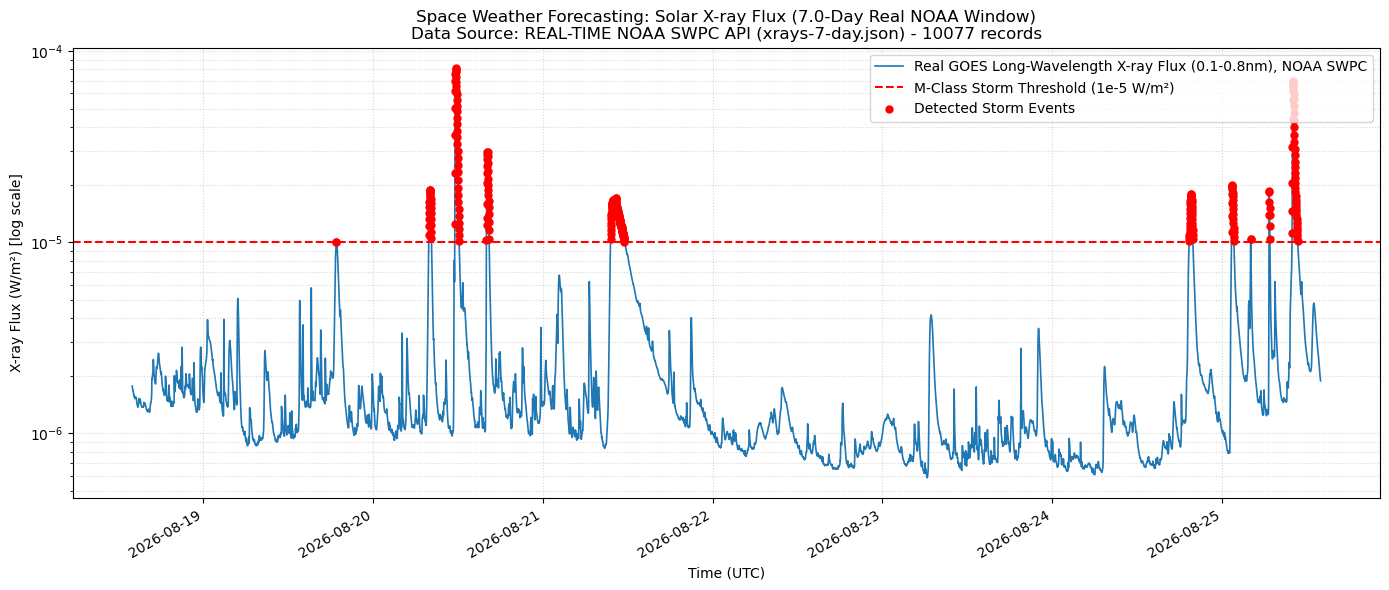


PoC COMPLETE. Ready for Intel AI Global Impact Festival pitch.


In [7]:
print("=" * 80)
print("STEP 5: Generating Visualization -> solar_storm_graph.png")
print("=" * 80)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df["time"], df["long_flux"], color="#1f77b4", linewidth=1.2,
        label="Real GOES Long-Wavelength X-ray Flux (0.1-0.8nm), NOAA SWPC")

ax.axhline(y=STORM_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
           label="M-Class Storm Threshold (1e-5 W/m\u00b2)")

storms = df[df["long_flux"] > STORM_THRESHOLD]
if not storms.empty:
    ax.scatter(storms["time"], storms["long_flux"], color="red", s=25,
               zorder=5, label="Detected Storm Events")

ax.set_yscale("log")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("X-ray Flux (W/m\u00b2) [log scale]")
ax.set_title(f"Space Weather Forecasting: Solar X-ray Flux ({span_days:.1f}-Day Real NOAA Window)\nData Source: {data_source}")
ax.legend(loc="upper right")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig("solar_storm_graph.png", dpi=150)
print("[OK] Plot saved as 'solar_storm_graph.png'")
plt.show()

print("\n" + "=" * 80)
print("PoC COMPLETE. Ready for Intel AI Global Impact Festival pitch.")
print("=" * 80)
